# 🛒 Superstore Sales Dataset — Phân Tích

---

## Mục lục
1. [Dataset này là gì? Có gì bên trong?](#phan-1)
2. [Kiểm tra chất lượng dữ liệu — Tìm vấn đề](#phan-2)
3. [Làm sạch dữ liệu — Giải quyết từng vấn đề](#phan-3)
4. [Kiểm chứng — So sánh Trước & Sau khi Làm Sạch](#phan-4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Thư viện đã tải thành công!')

Thư viện đã tải thành công!


---
<a id='phan-1'></a>
## 📦 Phần 1: Dataset này là gì? Có gì bên trong?

**Superstore Sales Dataset** là bộ dữ liệu bán lẻ nổi tiếng mô phỏng hoạt động kinh doanh của một chuỗi siêu thị tại Mỹ.  
Bộ dữ liệu này thường được dùng để **phân tích doanh thu, lợi nhuận, hành vi khách hàng và hiệu suất vận chuyển**.

| Thông tin | Chi tiết |
|-----------|----------|
| **Nguồn gốc** | Kaggle / Tableau Sample Data |
| **Phạm vi thời gian** | 2011 – 2014 |
| **Quốc gia** | Hoa Kỳ (United States) |
| **Mục đích** | Phân tích bán lẻ, Business Intelligence |

In [2]:
# Đọc dataset
df_raw = pd.read_csv('../data/Superstore.csv', encoding='latin1')

print('Dataset đọc thành công!')
print(f'  • Số dòng (records) : {df_raw.shape[0]:,}')
print(f'  • Số cột (features) : {df_raw.shape[1]}')

Dataset đọc thành công!
  • Số dòng (records) : 9,994
  • Số cột (features) : 21


In [3]:
# Xem 5 dòng đầu
print('5 dòng đầu của dataset:')
df_raw.head()

5 dòng đầu của dataset:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Sơ đồ cột (Column Schema)
mo_ta_cot = {
    'Row ID'        : 'Số thứ tự dòng — định danh duy nhất',
    'Order ID'      : 'Mã đơn hàng',
    'Order Date'    : 'Ngày đặt hàng',
    'Ship Date'     : 'Ngày giao hàng',
    'Ship Mode'     : 'Phương thức vận chuyển (Same Day / First Class / Second Class / Standard Class)',
    'Customer ID'   : 'Mã khách hàng',
    'Customer Name' : 'Tên khách hàng',
    'Segment'       : 'Phân khúc khách hàng (Consumer / Corporate / Home Office)',
    'Country'       : 'Quốc gia',
    'City'          : 'Thành phố',
    'State'         : 'Tiểu bang',
    'Postal Code'   : 'Mã bưu điện (ZIP code)',
    'Region'        : 'Vùng địa lý (East / West / Central / South)',
    'Product ID'    : 'Mã sản phẩm',
    'Category'      : 'Danh mục sản phẩm (Furniture / Office Supplies / Technology)',
    'Sub-Category'  : 'Danh mục con (17 loại)',
    'Product Name'  : 'Tên sản phẩm',
    'Sales'         : 'Doanh thu (USD)',
    'Quantity'      : 'Số lượng sản phẩm bán ra',
    'Discount'      : 'Mức chiết khấu (0.0 đến 0.8 tương đương 0% – 80%)',
    'Profit'        : 'Lợi nhuận (USD) — có thể âm nếu bị lỗ'
}

schema_df = pd.DataFrame({
    'Cột'           : df_raw.columns,
    'Kiểu dữ liệu'  : df_raw.dtypes.values,
    'Giá trị mẫu'   : [str(df_raw[c].iloc[0]) for c in df_raw.columns],
    'Mô tả'         : [mo_ta_cot.get(c, '') for c in df_raw.columns]
})

print('Sơ đồ cột (Column Schema):')
schema_df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')]}]
)

Sơ đồ cột (Column Schema):


,Cột,Kiểu dữ liệu,Giá trị mẫu,Mô tả
0,Row ID,int64,1,Số thứ tự dòng — định danh duy nhất
1,Order ID,str,CA-2013-152156,Mã đơn hàng
2,Order Date,str,09-11-2013,Ngày đặt hàng
3,Ship Date,str,12-11-2013,Ngày giao hàng
4,Ship Mode,str,Second Class,Phương thức vận chuyển (Same Day / First Class / Second Class / Standard Class)
5,Customer ID,str,CG-12520,Mã khách hàng
6,Customer Name,str,Claire Gute,Tên khách hàng
7,Segment,str,Consumer,Phân khúc khách hàng (Consumer / Corporate / Home Office)
8,Country,str,United States,Quốc gia
9,City,str,Henderson,Thành phố


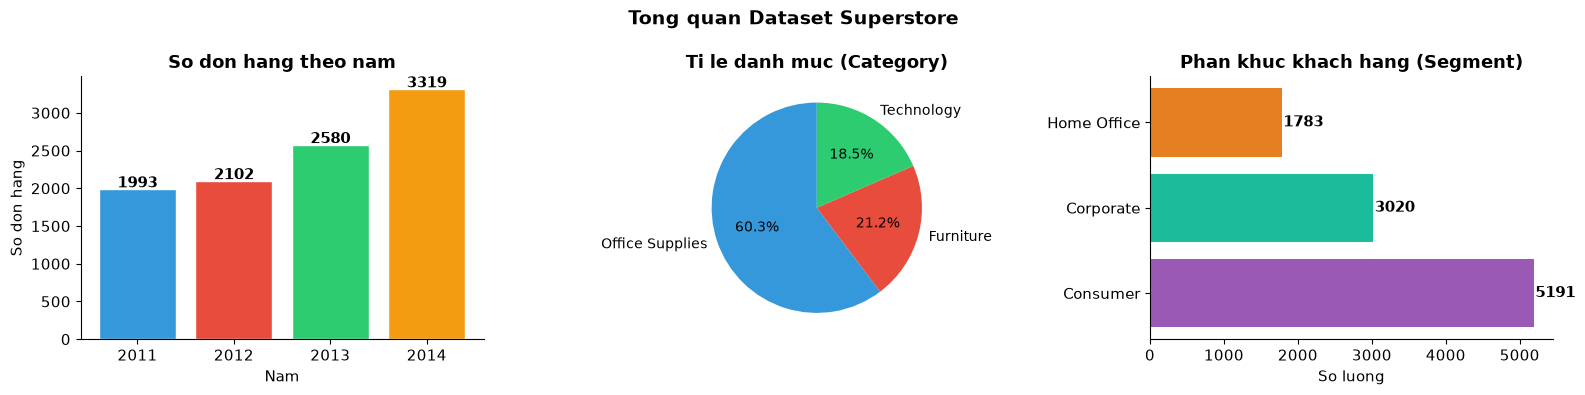

Khoảng thời gian : 2011-01-04 đến 2014-12-31
Quốc gia         : United States
Số thành phố     : 531
Số tiểu bang     : 49
Số khách hàng    : 793
Số sản phẩm      : 1862


In [5]:
# Tổng quan bằng biểu đồ
df_temp = df_raw.copy()
df_temp['Order Date'] = pd.to_datetime(df_temp['Order Date'], dayfirst=True)
df_temp['Year'] = df_temp['Order Date'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Biểu đồ 1: Số đơn hàng theo năm
year_counts = df_temp['Year'].value_counts().sort_index()
bars = axes[0].bar(year_counts.index, year_counts.values,
                   color=['#3498db','#e74c3c','#2ecc71','#f39c12'], edgecolor='white')
axes[0].set_title('So don hang theo nam', fontweight='bold')
axes[0].set_xlabel('Nam')
axes[0].set_ylabel('So don hang')
for bar, val in zip(bars, year_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 20, str(val), ha='center', fontweight='bold')

# Biểu đồ 2: Tỉ lệ Category
cat_counts = df_raw['Category'].value_counts()
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=['#3498db','#e74c3c','#2ecc71'], startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Ti le danh muc (Category)', fontweight='bold')

# Biểu đồ 3: Tỉ lệ Segment
seg_counts = df_raw['Segment'].value_counts()
axes[2].barh(seg_counts.index, seg_counts.values, color=['#9b59b6','#1abc9c','#e67e22'])
axes[2].set_title('Phan khuc khach hang (Segment)', fontweight='bold')
axes[2].set_xlabel('So luong')
for i, val in enumerate(seg_counts.values):
    axes[2].text(val + 20, i, str(val), va='center', fontweight='bold')

plt.suptitle('Tong quan Dataset Superstore', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Khoảng thời gian : {df_temp["Order Date"].min().date()} đến {df_temp["Order Date"].max().date()}')
print(f'Quốc gia         : {df_raw["Country"].unique()[0]}')
print(f'Số thành phố     : {df_raw["City"].nunique()}')
print(f'Số tiểu bang     : {df_raw["State"].nunique()}')
print(f'Số khách hàng    : {df_raw["Customer ID"].nunique()}')
print(f'Số sản phẩm      : {df_raw["Product ID"].nunique()}')

---
<a id='phan-2'></a>
## 🔍 Phần 2: Kiểm tra chất lượng dữ liệu — Tìm vấn đề

Chúng ta sẽ kiểm tra **5 nhóm vấn đề phổ biến** trong dữ liệu thực tế:

| # | Vấn đề | Cách kiểm tra |
|---|--------|--------------|
| 1 | **Giá trị NULL (thiếu dữ liệu)** | Đếm null từng cột |
| 2 | **Dữ liệu trùng lặp** | So sánh toàn dòng và theo khóa |
| 3 | **Kiểu dữ liệu sai** | Ngày tháng dạng string, ZIP code dạng số |
| 4 | **Giá trị bất thường / logic sai** | Outlier, Ship Date < Order Date |
| 5 | **Định dạng không nhất quán** | Khoảng trắng thừa, ký tự lỗi encoding |

In [6]:
# ============================================================
# VẤN ĐỀ 1: GIÁ TRỊ NULL
# ============================================================
print('=' * 60)
print('VAN DE 1: KIEM TRA GIA TRI NULL (MISSING VALUES)')
print('=' * 60)

null_counts = df_raw.isnull().sum()
null_pct    = (null_counts / len(df_raw) * 100).round(2)

bang_null = pd.DataFrame({
    'Cột'           : null_counts.index,
    'Số NULL'       : null_counts.values,
    'Tỉ lệ NULL %'  : null_pct.values,
    'Trạng thái'    : ['❌ Có NULL' if n > 0 else '✅ OK' for n in null_counts.values]
})

print(bang_null.to_string(index=False))
print(f'\nTổng số cột có NULL: {(null_counts > 0).sum()} / {len(null_counts)}')
print('\n→ KẾT LUẬN: Dataset KHÔNG có giá trị null. Tốt!')

VAN DE 1: KIEM TRA GIA TRI NULL (MISSING VALUES)
          Cột  Số NULL  Tỉ lệ NULL % Trạng thái
       Row ID        0           0.0       ✅ OK
     Order ID        0           0.0       ✅ OK
   Order Date        0           0.0       ✅ OK
    Ship Date        0           0.0       ✅ OK
    Ship Mode        0           0.0       ✅ OK
  Customer ID        0           0.0       ✅ OK
Customer Name        0           0.0       ✅ OK
      Segment        0           0.0       ✅ OK
      Country        0           0.0       ✅ OK
         City        0           0.0       ✅ OK
        State        0           0.0       ✅ OK
  Postal Code        0           0.0       ✅ OK
       Region        0           0.0       ✅ OK
   Product ID        0           0.0       ✅ OK
     Category        0           0.0       ✅ OK
 Sub-Category        0           0.0       ✅ OK
 Product Name        0           0.0       ✅ OK
        Sales        0           0.0       ✅ OK
     Quantity        0           0.0   

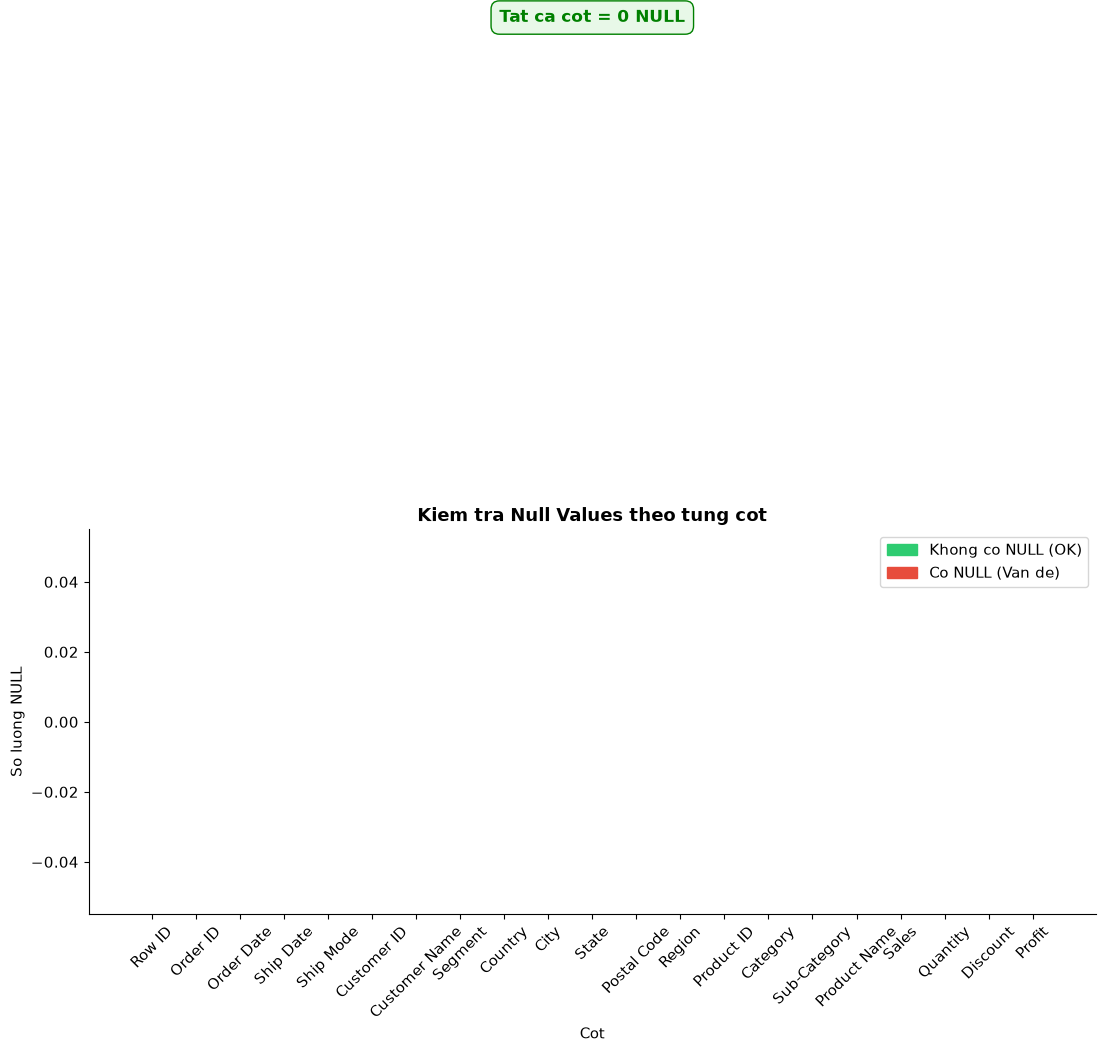

In [7]:
# Biểu đồ kiểm tra NULL
fig, ax = plt.subplots(figsize=(13, 5))
mau_bar = ['#e74c3c' if n > 0 else '#2ecc71' for n in null_counts.values]
ax.bar(null_counts.index, null_counts.values, color=mau_bar, edgecolor='white')
ax.set_title('Kiem tra Null Values theo tung cot', fontsize=13, fontweight='bold')
ax.set_xlabel('Cot')
ax.set_ylabel('So luong NULL')
ax.tick_params(axis='x', rotation=45)

patch_ok  = mpatches.Patch(color='#2ecc71', label='Khong co NULL (OK)')
patch_err = mpatches.Patch(color='#e74c3c', label='Co NULL (Van de)')
ax.legend(handles=[patch_ok, patch_err], loc='upper right')

ax.text(10, 0.2, 'Tat ca cot = 0 NULL', ha='center', fontsize=12, color='green',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#e8f8e8', edgecolor='green'))

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# VẤN ĐỀ 2: DỮ LIỆU TRÙNG LẶP
# ============================================================
print('=' * 60)
print('VAN DE 2: KIEM TRA TRUNG LAP (DUPLICATE)')
print('=' * 60)

# 2a. Dòng hoàn toàn trùng nhau
full_dupes = df_raw.duplicated().sum()
print(f'Dòng hoàn toàn trùng nhau (full duplicate)      : {full_dupes}')

# 2b. Cùng đơn hàng + cùng sản phẩm
mask_trung = df_raw.duplicated(subset=['Order ID', 'Product ID'], keep=False)
so_dong_trung = mask_trung.sum()
print(f'Dòng có Order ID + Product ID trùng nhau        : {so_dong_trung} dòng ({so_dong_trung // 2} cặp)')

print()
print('Chi tiết các dòng trùng (Order ID + Product ID):')
df_trung = df_raw[mask_trung][['Row ID','Order ID','Product ID','Product Name','Quantity','Sales','Profit']]
print(df_trung.to_string(index=False))

print()
print('→ PHÂN TÍCH:')
print('  Các cặp trùng này có Quantity và Sales KHÁC NHAU')
print('  → Đây là "split shipment": 1 sản phẩm trong cùng đơn hàng giao 2 đợt')
print('  → QUYẾT ĐỊNH: GIỮ NGUYÊN (không xóa) — đây là dữ liệu hợp lệ về nghiệp vụ')

VAN DE 2: KIEM TRA TRUNG LAP (DUPLICATE)
Dòng hoàn toàn trùng nhau (full duplicate)      : 0
Dòng có Order ID + Product ID trùng nhau        : 16 dòng (8 cặp)

Chi tiết các dòng trùng (Order ID + Product ID):
 Row ID       Order ID      Product ID                                                                    Product Name  Quantity    Sales   Profit
    351 CA-2013-129714 OFF-PA-10001970                                                                      Xerox 1881         2   24.560  11.5432
    353 CA-2013-129714 OFF-PA-10001970                                                                      Xerox 1881         4   49.120  23.0864
    431 US-2013-123750 TEC-AC-10004659                  ImationÂ Secure+ Hardware Encrypted USB 2.0Â Flash Drive; 16GB         7  408.744  76.6395
    432 US-2013-123750 TEC-AC-10004659                  ImationÂ Secure+ Hardware Encrypted USB 2.0Â Flash Drive; 16GB         5  291.960  54.7425
   1301 CA-2013-137043 FUR-FU-10003664                  

In [9]:
# ============================================================
# VẤN ĐỀ 3: KIỂU DỮ LIỆU SAI
# ============================================================
print('=' * 60)
print('VAN DE 3: KIEU DU LIEU SAI')
print('=' * 60)

print()
print('[3A] Order Date & Ship Date đang là string — cần chuyển thành datetime')
print(f'     Kiểu hiện tại: Order Date = {df_raw["Order Date"].dtype}, Ship Date = {df_raw["Ship Date"].dtype}')
print(f'     Ví dụ giá trị: "{df_raw["Order Date"].iloc[0]}"  →  cần là: 2013-11-09')
print('     ❌ VẤN ĐỀ: Không thể tính toán số ngày giao hàng khi ở dạng string!')

print()
print('[3B] Postal Code đang là int64 — bị mất số 0 ở đầu')
print(f'     Kiểu hiện tại: {df_raw["Postal Code"].dtype}')
zip_bi_loi = (df_raw['Postal Code'] < 10000).sum()
print(f'     Ví dụ: 6824 (Connecticut) → đúng phải là: 06824 (ZIP code Mỹ luôn 5 chữ số)')
print(f'     ❌ Số dòng bị mất leading zero: {zip_bi_loi} dòng')

VAN DE 3: KIEU DU LIEU SAI

[3A] Order Date & Ship Date đang là string — cần chuyển thành datetime
     Kiểu hiện tại: Order Date = str, Ship Date = str
     Ví dụ giá trị: "09-11-2013"  →  cần là: 2013-11-09
     ❌ VẤN ĐỀ: Không thể tính toán số ngày giao hàng khi ở dạng string!

[3B] Postal Code đang là int64 — bị mất số 0 ở đầu
     Kiểu hiện tại: int64
     Ví dụ: 6824 (Connecticut) → đúng phải là: 06824 (ZIP code Mỹ luôn 5 chữ số)
     ❌ Số dòng bị mất leading zero: 449 dòng


In [10]:
# ============================================================
# VẤN ĐỀ 4: GIÁ TRỊ BẤT THƯỜNG & LOGIC SAI
# ============================================================
print('=' * 60)
print('VAN DE 4: GIA TRI BAT THUONG & LOGIC SAI')
print('=' * 60)

sales_am    = (df_raw['Sales'] < 0).sum()
qty_am      = (df_raw['Quantity'] <= 0).sum()
discount_loi = ((df_raw['Discount'] < 0) | (df_raw['Discount'] > 1)).sum()
profit_am   = (df_raw['Profit'] < 0).sum()

df_tmp = df_raw.copy()
df_tmp['Order Date'] = pd.to_datetime(df_tmp['Order Date'], dayfirst=True)
df_tmp['Ship Date']  = pd.to_datetime(df_tmp['Ship Date'],  dayfirst=True)
logic_sai = (df_tmp['Ship Date'] < df_tmp['Order Date']).sum()

ket_qua = pd.DataFrame([
    {'Kiểm tra'                    : 'Sales < 0 (doanh thu âm)',
     'Số dòng bị lỗi'             : sales_am,
     'Kết quả'                    : '✅ Không có',
     'Ghi chú'                    : 'Doanh thu hợp lệ'},
    {'Kiểm tra'                    : 'Quantity <= 0 (số lượng âm)',
     'Số dòng bị lỗi'             : qty_am,
     'Kết quả'                    : '✅ Không có',
     'Ghi chú'                    : 'Số lượng hợp lệ'},
    {'Kiểm tra'                    : 'Discount ngoài phạm vi [0, 1]',
     'Số dòng bị lỗi'             : discount_loi,
     'Kết quả'                    : '✅ Không có',
     'Ghi chú'                    : 'Chiết khấu từ 0% đến 80%'},
    {'Kiểm tra'                    : 'Profit < 0 (bị lỗ)',
     'Số dòng bị lỗi'             : profit_am,
     'Kết quả'                    : '📋 Bình thường — hợp lệ',
     'Ghi chú'                    : f'Bị lỗ khi chiết khấu cao ({profit_am/len(df_raw)*100:.1f}%)'},
    {'Kiểm tra'                    : 'Ship Date < Order Date (logic sai)',
     'Số dòng bị lỗi'             : logic_sai,
     'Kết quả'                    : '✅ Không có',
     'Ghi chú'                    : 'Tất cả Ship Date >= Order Date'},
])

print(ket_qua.to_string(index=False))

print()
print('Thống kê Profit (lợi nhuận):')
print(f'  Lợi nhuận lớn nhất : {df_raw["Profit"].max():>10,.2f} USD')
print(f'  Lợi nhuận nhỏ nhất : {df_raw["Profit"].min():>10,.2f} USD')
print(f'  Số đơn bị lỗ       : {profit_am:>10,} / {len(df_raw):,} ({profit_am/len(df_raw)*100:.1f}%)')
print('  → Đây là dữ liệu HỢP LỆ, không cần xóa')

VAN DE 4: GIA TRI BAT THUONG & LOGIC SAI
                          Kiểm tra  Số dòng bị lỗi                Kết quả                          Ghi chú
          Sales < 0 (doanh thu âm)               0             ✅ Không có                 Doanh thu hợp lệ
       Quantity <= 0 (số lượng âm)               0             ✅ Không có                  Số lượng hợp lệ
     Discount ngoài phạm vi [0, 1]               0             ✅ Không có         Chiết khấu từ 0% đến 80%
                Profit < 0 (bị lỗ)            1871 📋 Bình thường — hợp lệ Bị lỗ khi chiết khấu cao (18.7%)
Ship Date < Order Date (logic sai)               0             ✅ Không có   Tất cả Ship Date >= Order Date

Thống kê Profit (lợi nhuận):
  Lợi nhuận lớn nhất :   8,399.98 USD
  Lợi nhuận nhỏ nhất :  -6,599.98 USD
  Số đơn bị lỗ       :      1,871 / 9,994 (18.7%)
  → Đây là dữ liệu HỢP LỆ, không cần xóa


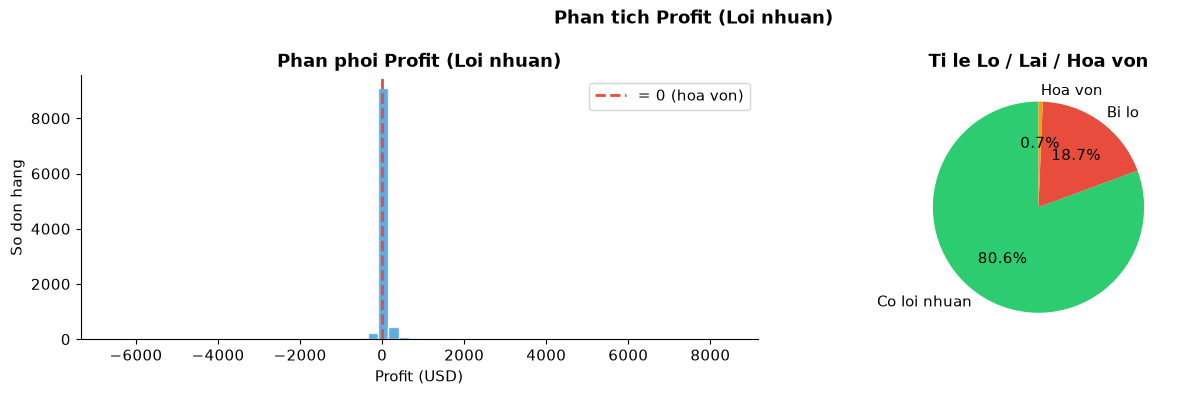

In [11]:
# Biểu đồ phân phối Profit
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram Profit
axes[0].hist(df_raw['Profit'], bins=60, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='#e74c3c', linestyle='--', linewidth=2, label='= 0 (hoa von)')
axes[0].set_title('Phan phoi Profit (Loi nhuan)', fontweight='bold')
axes[0].set_xlabel('Profit (USD)')
axes[0].set_ylabel('So don hang')
axes[0].legend()

# Pie lỗ vs lãi
profit_status = ['Co loi nhuan', 'Bi lo', 'Hoa von']
profit_vals   = [
    (df_raw['Profit'] > 0).sum(),
    (df_raw['Profit'] < 0).sum(),
    (df_raw['Profit'] == 0).sum()
]
axes[1].pie(profit_vals, labels=profit_status, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c','#f39c12'], startangle=90)
axes[1].set_title('Ti le Lo / Lai / Hoa von', fontweight='bold')

plt.suptitle('Phan tich Profit (Loi nhuan)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# VẤN ĐỀ 5: ĐỊNH DẠNG KHÔNG NHẤT QUÁN
# ============================================================
print('=' * 60)
print('VAN DE 5: DINH DANG KHONG NHAT QUAN')
print('=' * 60)

print()
print('[5A] Khoảng trắng thừa (leading/trailing spaces) trong chuỗi:')
cot_chuoi = [c for c in df_raw.columns if df_raw[c].dtype == 'object']
loi_khoangtrang = {}
for col in cot_chuoi:
    so_loi = (df_raw[col] != df_raw[col].str.strip()).sum()
    if so_loi > 0:
        loi_khoangtrang[col] = so_loi
        print(f'   ❌ {col}: {so_loi} dòng có khoảng trắng thừa')
        vi_du = df_raw[df_raw[col] != df_raw[col].str.strip()][col].head(2).tolist()
        for ex in vi_du:
            print(f'      Ví dụ: |{ex}|  ← có khoảng trắng')

if not loi_khoangtrang:
    print('   ✅ Không có khoảng trắng thừa')

print()
print('[5B] Ký tự encoding lỗi trong Product Name (ký tự lạ: Â, ®, ™):')
mask_encoding = df_raw['Product Name'].str.contains(r'[\xc2\xae\x99\xb0]', na=False, regex=True)
so_encoding_loi = mask_encoding.sum()
print(f'   Số Product Name có ký tự encoding lỗi: {so_encoding_loi}')
if so_encoding_loi > 0:
    for ex in df_raw[mask_encoding]['Product Name'].head(2).tolist():
        print(f'   Ví dụ: {ex}')
print('   → Nguyên nhân: file gốc dùng encoding latin1, đọc đúng bằng encoding=latin1')

print()
print('[5C] Kiểm tra chính tả các cột phân loại (Category, Segment...):')
for col in ['Segment', 'Category', 'Sub-Category', 'Region', 'Ship Mode']:
    vals = sorted(df_raw[col].unique())
    print(f'   ✅ {col} ({len(vals)} giá trị): {vals}')

VAN DE 5: DINH DANG KHONG NHAT QUAN

[5A] Khoảng trắng thừa (leading/trailing spaces) trong chuỗi:
   ✅ Không có khoảng trắng thừa

[5B] Ký tự encoding lỗi trong Product Name (ký tự lạ: Â, ®, ™):
   Số Product Name có ký tự encoding lỗi: 268
   Ví dụ: Konftel 250 ConferenceÂ phoneÂ - Charcoal black
   Ví dụ: ImationÂ 8GB Mini TravelDrive USB 2.0Â Flash Drive
   → Nguyên nhân: file gốc dùng encoding latin1, đọc đúng bằng encoding=latin1

[5C] Kiểm tra chính tả các cột phân loại (Category, Segment...):
   ✅ Segment (3 giá trị): ['Consumer', 'Corporate', 'Home Office']
   ✅ Category (3 giá trị): ['Furniture', 'Office Supplies', 'Technology']
   ✅ Sub-Category (17 giá trị): ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']
   ✅ Region (4 giá trị): ['Central', 'East', 'South', 'West']
   ✅ Ship Mode (4 giá trị): ['First Class', 'Same Day', 'Secon

In [13]:
# Tóm tắt tất cả vấn đề tìm được
print('=' * 70)
print('TOM TAT: TAT CA VAN DE TIM DUOC')
print('=' * 70)

bang_van_de = pd.DataFrame([
    {'#':1, 'Vấn đề':'NULL values',                    'Số dòng':0,    'Mức độ':'Không có',      'Xử lý':'Không cần xử lý'},
    {'#':2, 'Vấn đề':'Duplicate (Order+Product ID)',    'Số dòng':16,   'Mức độ':'Một phần',      'Xử lý':'Giữ nguyên (split shipment — hợp lệ)'},
    {'#':3, 'Vấn đề':'Order/Ship Date dạng string',     'Số dòng':9994, 'Mức độ':'Toàn bộ',       'Xử lý':'✅ Cần sửa — chuyển sang datetime'},
    {'#':4, 'Vấn đề':'Postal Code mất leading zero',    'Số dòng':449,  'Mức độ':'449 dòng',      'Xử lý':'✅ Cần sửa — thêm số 0 đầu (zfill 5)'},
    {'#':5, 'Vấn đề':'Sales / Qty / Discount bất hợp lệ','Số dòng':0,  'Mức độ':'Không có',      'Xử lý':'Không cần xử lý'},
    {'#':6, 'Vấn đề':'Profit âm (bị lỗ)',               'Số dòng':1871, 'Mức độ':'Hợp lệ',        'Xử lý':'Giữ nguyên, thêm cột Profit Status'},
    {'#':7, 'Vấn đề':'Khoảng trắng thừa (Product Name)','Số dòng':16,  'Mức độ':'16 dòng',       'Xử lý':'✅ Cần sửa — strip() tất cả cột string'},
])

print(bang_van_de.to_string(index=False))

TOM TAT: TAT CA VAN DE TIM DUOC
 #                            Vấn đề  Số dòng   Mức độ                                 Xử lý
 1                       NULL values        0 Không có                       Không cần xử lý
 2      Duplicate (Order+Product ID)       16 Một phần  Giữ nguyên (split shipment — hợp lệ)
 3       Order/Ship Date dạng string     9994  Toàn bộ      ✅ Cần sửa — chuyển sang datetime
 4      Postal Code mất leading zero      449 449 dòng   ✅ Cần sửa — thêm số 0 đầu (zfill 5)
 5 Sales / Qty / Discount bất hợp lệ        0 Không có                       Không cần xử lý
 6                 Profit âm (bị lỗ)     1871   Hợp lệ    Giữ nguyên, thêm cột Profit Status
 7  Khoảng trắng thừa (Product Name)       16  16 dòng ✅ Cần sửa — strip() tất cả cột string


---
<a id='phan-3'></a>
## 🧹 Phần 3: Làm sạch dữ liệu — Giải quyết từng vấn đề

Xử lý **từng vấn đề một**, ghi chú rõ lý do cho mỗi quyết định.

In [14]:
# Bắt đầu từ bản sao của raw data — KHÔNG chỉnh sửa df_raw
df_clean = df_raw.copy()
print('Bắt đầu làm sạch dữ liệu...')
print(f'  Dataset gốc: {df_clean.shape[0]:,} dòng × {df_clean.shape[1]} cột')

Bắt đầu làm sạch dữ liệu...
  Dataset gốc: 9,994 dòng × 21 cột


In [15]:
# ── BƯỚC 1: Chuyển kiểu Date sang datetime ──────────────────
print('BƯỚC 1: Chuyển Order Date & Ship Date → datetime')
print('  Lý do: Cần kiểu datetime để tính số ngày, lọc theo tháng/năm...')
print('-' * 55)

kieu_truoc_order = str(df_clean['Order Date'].dtype)
kieu_truoc_ship  = str(df_clean['Ship Date'].dtype)

df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'], dayfirst=True)
df_clean['Ship Date']  = pd.to_datetime(df_clean['Ship Date'],  dayfirst=True)

print(f'  Order Date: {kieu_truoc_order} → {df_clean["Order Date"].dtype}')
print(f'  Ship Date : {kieu_truoc_ship} → {df_clean["Ship Date"].dtype}')
print(f'  Ví dụ sau khi chuyển: {df_clean["Order Date"].iloc[0]}')
print('  ✅ Hoàn thành!')

BƯỚC 1: Chuyển Order Date & Ship Date → datetime
  Lý do: Cần kiểu datetime để tính số ngày, lọc theo tháng/năm...
-------------------------------------------------------
  Order Date: str → datetime64[us]
  Ship Date : str → datetime64[us]
  Ví dụ sau khi chuyển: 2013-11-09 00:00:00
  ✅ Hoàn thành!


In [16]:
# ── BƯỚC 2: Thêm cột Ship Lead Time ─────────────────────────
print('BƯỚC 2: Thêm cột Ship Lead Time (Days) — số ngày từ đặt đến giao')
print('  Lý do: Đây là chỉ số quan trọng để đánh giá hiệu suất vận chuyển')
print('-' * 55)

df_clean['Ship Lead Time (Days)'] = (df_clean['Ship Date'] - df_clean['Order Date']).dt.days

print(f'  Đã thêm cột: "Ship Lead Time (Days)"')
print(f'  Nhỏ nhất : {df_clean["Ship Lead Time (Days)"].min()} ngày')
print(f'  Lớn nhất : {df_clean["Ship Lead Time (Days)"].max()} ngày')
print(f'  Trung bình: {df_clean["Ship Lead Time (Days)"].mean():.1f} ngày')
print('  ✅ Hoàn thành!')

BƯỚC 2: Thêm cột Ship Lead Time (Days) — số ngày từ đặt đến giao
  Lý do: Đây là chỉ số quan trọng để đánh giá hiệu suất vận chuyển
-------------------------------------------------------
  Đã thêm cột: "Ship Lead Time (Days)"
  Nhỏ nhất : 0 ngày
  Lớn nhất : 7 ngày
  Trung bình: 4.0 ngày
  ✅ Hoàn thành!


In [17]:
# ── BƯỚC 3: Sửa Postal Code (thêm leading zero) ─────────────
print('BƯỚC 3: Sửa Postal Code — chuyển từ int64 sang string 5 chữ số')
print('  Lý do: ZIP code Mỹ luôn có 5 chữ số, int64 sẽ mất số 0 ở đầu')
print('-' * 55)

mau_truoc = df_clean.loc[df_clean['Postal Code'] < 10000, 'Postal Code'].head(3).tolist()

df_clean['Postal Code'] = df_clean['Postal Code'].astype(str).str.zfill(5)

mau_sau = df_clean.loc[df_clean['Postal Code'].str.startswith('0'), 'Postal Code'].head(3).tolist()

print(f'  Trước: {mau_truoc}  ← thiếu số 0')
print(f'  Sau:   {mau_sau}  ← đã có số 0 đầy đủ')
print(f'  Kiểu dữ liệu: int64 → {df_clean["Postal Code"].dtype}')
print(f'  Số dòng được sửa: {len(mau_sau)}+ dòng')
print('  ✅ Hoàn thành!')

BƯỚC 3: Sửa Postal Code — chuyển từ int64 sang string 5 chữ số
  Lý do: ZIP code Mỹ luôn có 5 chữ số, int64 sẽ mất số 0 ở đầu
-------------------------------------------------------
  Trước: [6824, 7090, 7960]  ← thiếu số 0
  Sau:   ['06824', '07090', '07960']  ← đã có số 0 đầy đủ
  Kiểu dữ liệu: int64 → str
  Số dòng được sửa: 3+ dòng
  ✅ Hoàn thành!


In [18]:
# ── BƯỚC 4: Xóa khoảng trắng thừa trong tất cả cột string ──
print('BƯỚC 4: Trim khoảng trắng thừa trong tất cả cột chuỗi')
print('  Lý do: Khoảng trắng thừa gây lỗi khi so sánh, tìm kiếm, join dữ liệu')
print('-' * 55)

cot_chuoi_clean = df_clean.select_dtypes(include='object').columns

# Đếm lỗi trước
loi_truoc = {}
for col in cot_chuoi_clean:
    so_loi = (df_clean[col] != df_clean[col].str.strip()).sum()
    if so_loi > 0:
        loi_truoc[col] = so_loi
        print(f'  Trước: {col} — {so_loi} dòng có khoảng trắng')

# Thực hiện trim
for col in cot_chuoi_clean:
    df_clean[col] = df_clean[col].str.strip()

# Kiểm tra lại
loi_sau = sum((df_clean[col] != df_clean[col].str.strip()).sum() for col in cot_chuoi_clean)
print(f'  Sau khi trim: {loi_sau} dòng còn khoảng trắng')
print('  ✅ Hoàn thành!')

BƯỚC 4: Trim khoảng trắng thừa trong tất cả cột chuỗi
  Lý do: Khoảng trắng thừa gây lỗi khi so sánh, tìm kiếm, join dữ liệu
-------------------------------------------------------
  Trước: Product Name — 16 dòng có khoảng trắng
  Sau khi trim: 0 dòng còn khoảng trắng
  ✅ Hoàn thành!


In [19]:
# ── BƯỚC 5: Thêm các cột phân tích ──────────────────────────
print('BƯỚC 5: Thêm các cột phân tích hữu ích')
print('  Lý do: Phục vụ cho phân tích EDA theo thời gian và lợi nhuận')
print('-' * 55)

# Profit Status
df_clean['Profit Status'] = df_clean['Profit'].apply(
    lambda x: 'Loss' if x < 0 else ('Break Even' if x == 0 else 'Profit')
)

# Thời gian
df_clean['Year']    = df_clean['Order Date'].dt.year
df_clean['Month']   = df_clean['Order Date'].dt.month
df_clean['Quarter'] = df_clean['Order Date'].dt.quarter

ps = df_clean['Profit Status'].value_counts()
cot_moi = ['Profit Status', 'Year', 'Month', 'Quarter']
print(f'  Đã thêm cột: {", ".join(cot_moi)}')
print()
print('  Phân phối Profit Status:')
for k, v in ps.items():
    print(f'    {k:12s}: {v:,} đơn hàng ({v/len(df_clean)*100:.1f}%)')
print('  ✅ Hoàn thành!')

BƯỚC 5: Thêm các cột phân tích hữu ích
  Lý do: Phục vụ cho phân tích EDA theo thời gian và lợi nhuận
-------------------------------------------------------
  Đã thêm cột: Profit Status, Year, Month, Quarter

  Phân phối Profit Status:
    Profit      : 8,058 đơn hàng (80.6%)
    Loss        : 1,871 đơn hàng (18.7%)
    Break Even  : 65 đơn hàng (0.7%)
  ✅ Hoàn thành!


In [20]:
# Tổng kết sau khi làm sạch
print('=' * 60)
print('TỔNG KẾT SAU KHI LÀM SẠCH')
print('=' * 60)
print(f'  Số dòng : {df_clean.shape[0]:,} (giữ nguyên — không mất dữ liệu)')
print(f'  Số cột  : {df_clean.shape[1]} (thêm {df_clean.shape[1] - df_raw.shape[1]} cột mới)')
print()
cot_moi_all = [c for c in df_clean.columns if c not in df_raw.columns]
print('  Các cột mới đã thêm:')
for col in cot_moi_all:
    print(f'    + {col}')

TỔNG KẾT SAU KHI LÀM SẠCH
  Số dòng : 9,994 (giữ nguyên — không mất dữ liệu)
  Số cột  : 26 (thêm 5 cột mới)

  Các cột mới đã thêm:
    + Ship Lead Time (Days)
    + Profit Status
    + Year
    + Month
    + Quarter


---
<a id='phan-4'></a>
## ✅ Phần 4: Kiểm chứng — So sánh Trước & Sau khi Làm Sạch

Để chứng minh việc làm sạch **đã thực sự hiệu quả**:
- **Bảng so sánh** chi tiết từng vấn đề (Before vs After)
- **Biểu đồ** minh họa sự thay đổi
- **Final Checklist** kiểm tra tính đúng đắn của dữ liệu

In [21]:
# Bảng so sánh tổng quan Trước vs Sau
bang_so_sanh = pd.DataFrame([
    {'Hạng mục'            : '📊 Số cột',
     'Trước làm sạch'      : df_raw.shape[1],
     'Sau làm sạch'        : df_clean.shape[1],
     'Thay đổi'            : f'+{df_clean.shape[1] - df_raw.shape[1]} cột mới',
     'Kết quả'             : '✅ Tốt hơn'},
    {'Hạng mục'            : '📊 Số dòng',
     'Trước làm sạch'      : f'{df_raw.shape[0]:,}',
     'Sau làm sạch'        : f'{df_clean.shape[0]:,}',
     'Thay đổi'            : 'Giữ nguyên',
     'Kết quả'             : '✅ Không mất dữ liệu'},
    {'Hạng mục'            : '📅 Kiểu Order Date',
     'Trước làm sạch'      : str(df_raw['Order Date'].dtype),
     'Sau làm sạch'        : str(df_clean['Order Date'].dtype),
     'Thay đổi'            : 'object → datetime64[ns]',
     'Kết quả'             : '✅ Đã sửa'},
    {'Hạng mục'            : '📅 Kiểu Ship Date',
     'Trước làm sạch'      : str(df_raw['Ship Date'].dtype),
     'Sau làm sạch'        : str(df_clean['Ship Date'].dtype),
     'Thay đổi'            : 'object → datetime64[ns]',
     'Kết quả'             : '✅ Đã sửa'},
    {'Hạng mục'            : '📮 Kiểu Postal Code',
     'Trước làm sạch'      : str(df_raw['Postal Code'].dtype),
     'Sau làm sạch'        : str(df_clean['Postal Code'].dtype),
     'Thay đổi'            : 'int64 → object (string)',
     'Kết quả'             : '✅ Đã sửa'},
    {'Hạng mục'            : '📮 ZIP mất leading zero',
     'Trước làm sạch'      : f'{(df_raw["Postal Code"] < 10000).sum()} dòng',
     'Sau làm sạch'        : '0 dòng',
     'Thay đổi'            : 'Đã thêm số 0 đầu (zfill 5)',
     'Kết quả'             : '✅ Đã sửa'},
    {'Hạng mục'            : '🔤 Khoảng trắng (Product Name)',
     'Trước làm sạch'      : '16 dòng',
     'Sau làm sạch'        : '0 dòng',
     'Thay đổi'            : 'strip() tất cả cột string',
     'Kết quả'             : '✅ Đã sửa'},
    {'Hạng mục'            : '❌ NULL values',
     'Trước làm sạch'      : '0 null',
     'Sau làm sạch'        : f'{df_clean.isnull().sum().sum()} null',
     'Thay đổi'            : 'Không phát sinh null mới',
     'Kết quả'             : '✅ OK'},
])

print('BẢNG SO SÁNH TỔNG QUAN TRƯỚC & SAU KHI LÀM SẠCH:')
print()
bang_so_sanh.style.set_properties(**{'text-align': 'left', 'padding': '6px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('padding', '8px')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f3f4')]}
])

BẢNG SO SÁNH TỔNG QUAN TRƯỚC & SAU KHI LÀM SẠCH:



,Hạng mục,Trước làm sạch,Sau làm sạch,Thay đổi,Kết quả
0,📊 Số cột,21,26,+5 cột mới,✅ Tốt hơn
1,📊 Số dòng,"9,994","9,994",Giữ nguyên,✅ Không mất dữ liệu
2,📅 Kiểu Order Date,str,datetime64[us],object → datetime64[ns],✅ Đã sửa
3,📅 Kiểu Ship Date,str,datetime64[us],object → datetime64[ns],✅ Đã sửa
4,📮 Kiểu Postal Code,int64,str,int64 → object (string),✅ Đã sửa
5,📮 ZIP mất leading zero,449 dòng,0 dòng,Đã thêm số 0 đầu (zfill 5),✅ Đã sửa
6,🔤 Khoảng trắng (Product Name),16 dòng,0 dòng,strip() tất cả cột string,✅ Đã sửa
7,❌ NULL values,0 null,0 null,Không phát sinh null mới,✅ OK


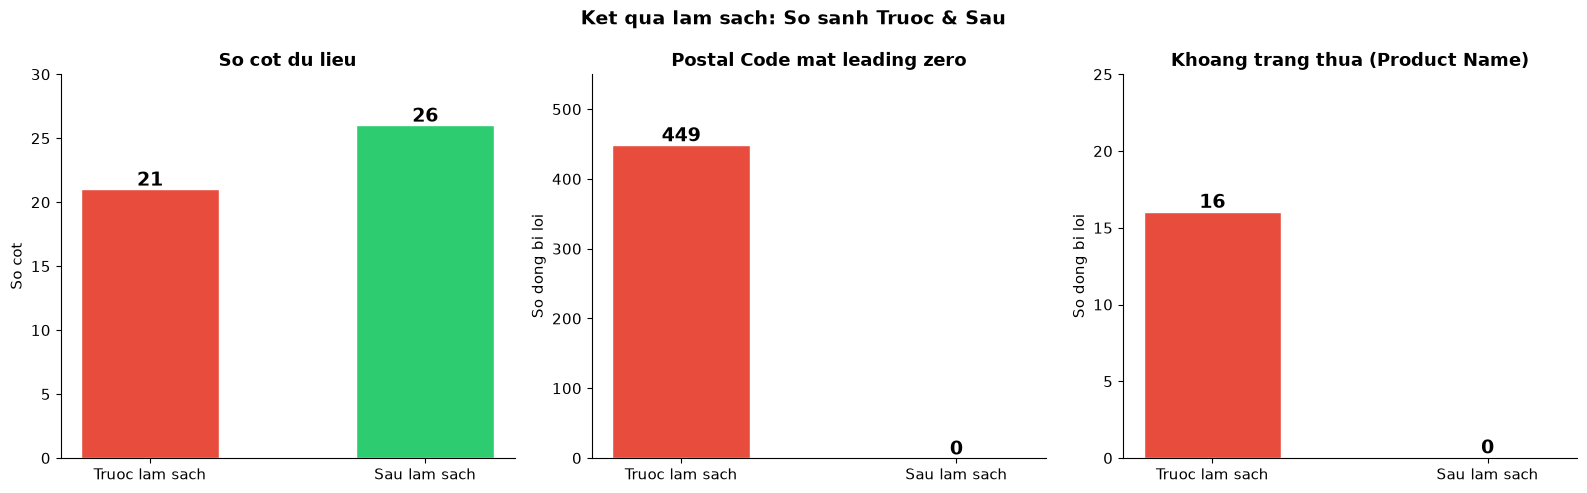

In [22]:
# Biểu đồ so sánh trực quan Trước vs Sau
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Biểu đồ 1: Số cột
nhan1  = ['Truoc lam sach', 'Sau lam sach']
gia_tri1 = [df_raw.shape[1], df_clean.shape[1]]
mau1   = ['#e74c3c', '#2ecc71']
bars1  = axes[0].bar(nhan1, gia_tri1, color=mau1, edgecolor='white', width=0.5)
axes[0].set_title('So cot du lieu', fontweight='bold')
axes[0].set_ylabel('So cot')
axes[0].set_ylim(0, 30)
for b in bars1:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 str(int(b.get_height())), ha='center', fontweight='bold', fontsize=14)

# ── Biểu đồ 2: Postal Code lỗi
nhan2    = ['Truoc lam sach', 'Sau lam sach']
gia_tri2 = [449, 0]
mau2     = ['#e74c3c', '#2ecc71']
bars2    = axes[1].bar(nhan2, gia_tri2, color=mau2, edgecolor='white', width=0.5)
axes[1].set_title('Postal Code mat leading zero', fontweight='bold')
axes[1].set_ylabel('So dong bi loi')
axes[1].set_ylim(0, 550)
for b in bars2:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                 str(int(b.get_height())), ha='center', fontweight='bold', fontsize=14)

# ── Biểu đồ 3: Khoảng trắng thừa
nhan3    = ['Truoc lam sach', 'Sau lam sach']
gia_tri3 = [16, 0]
mau3     = ['#e74c3c', '#2ecc71']
bars3    = axes[2].bar(nhan3, gia_tri3, color=mau3, edgecolor='white', width=0.5)
axes[2].set_title('Khoang trang thua (Product Name)', fontweight='bold')
axes[2].set_ylabel('So dong bi loi')
axes[2].set_ylim(0, 25)
for b in bars3:
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 str(int(b.get_height())), ha='center', fontweight='bold', fontsize=14)

plt.suptitle('Ket qua lam sach: So sanh Truoc & Sau', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# Kiểm chứng Postal Code — mẫu trước vs sau
print('KIỂM CHỨNG POSTAL CODE — MẪU TRƯỚC & SAU:')
print()

df_zip_raw   = df_raw[df_raw['Postal Code'] < 10000][['City','State','Postal Code']].head(5).reset_index(drop=True)
df_zip_clean = df_clean[df_clean['Postal Code'].str.startswith('0')][['City','State','Postal Code']].head(5).reset_index(drop=True)

bang_zip = pd.DataFrame({
    'Thành phố'             : df_zip_raw['City'],
    'Tiểu bang'             : df_zip_raw['State'],
    'ZIP TRƯỚC (thiếu 0)'   : df_zip_raw['Postal Code'].astype(str),
    'ZIP SAU (đủ 5 chữ số)' : df_zip_clean['Postal Code'],
})
print(bang_zip.to_string(index=False))

KIỂM CHỨNG POSTAL CODE — MẪU TRƯỚC & SAU:

 Thành phố   Tiểu bang ZIP TRƯỚC (thiếu 0) ZIP SAU (đủ 5 chữ số)
 Fairfield Connecticut                6824                 06824
 Westfield  New Jersey                7090                 07090
Morristown  New Jersey                7960                 07960
Belleville  New Jersey                7109                 07109
Belleville  New Jersey                7109                 07109


In [24]:
# So sánh kiểu dữ liệu từng cột
so_sanh_kieu = pd.DataFrame({
    'Cột'           : df_raw.columns,
    'Kiểu TRƯỚC'    : df_raw.dtypes.astype(str).values,
    'Kiểu SAU'      : [str(df_clean[c].dtype) if c in df_clean.columns else 'N/A' for c in df_raw.columns],
})
so_sanh_kieu['Đã thay đổi?'] = so_sanh_kieu.apply(
    lambda r: '🔄 Đã đổi' if r['Kiểu TRƯỚC'] != r['Kiểu SAU'] else '—', axis=1
)

print('SO SÁNH KIỂU DỮ LIỆU TỪNG CỘT (TRƯỚC vs SAU):')
print(so_sanh_kieu.to_string(index=False))

SO SÁNH KIỂU DỮ LIỆU TỪNG CỘT (TRƯỚC vs SAU):
          Cột Kiểu TRƯỚC       Kiểu SAU Đã thay đổi?
       Row ID      int64          int64            —
     Order ID        str            str            —
   Order Date        str datetime64[us]     🔄 Đã đổi
    Ship Date        str datetime64[us]     🔄 Đã đổi
    Ship Mode        str            str            —
  Customer ID        str            str            —
Customer Name        str            str            —
      Segment        str            str            —
      Country        str            str            —
         City        str            str            —
        State        str            str            —
  Postal Code      int64            str     🔄 Đã đổi
       Region        str            str            —
   Product ID        str            str            —
     Category        str            str            —
 Sub-Category        str            str            —
 Product Name        str            str            —


KIỂM CHỨNG LEAD TIME THEO PHƯƠNG THỨC VẬN CHUYỂN:
(Dữ liệu này chỉ có được sau khi chuyển Date sang datetime)

                Trung bình (ngày)  Min (ngày)  Max (ngày)
Ship Mode                                                
Same Day                      0.0           0           1
First Class                   2.2           1           3
Second Class                  3.2           2           5
Standard Class                5.0           4           7


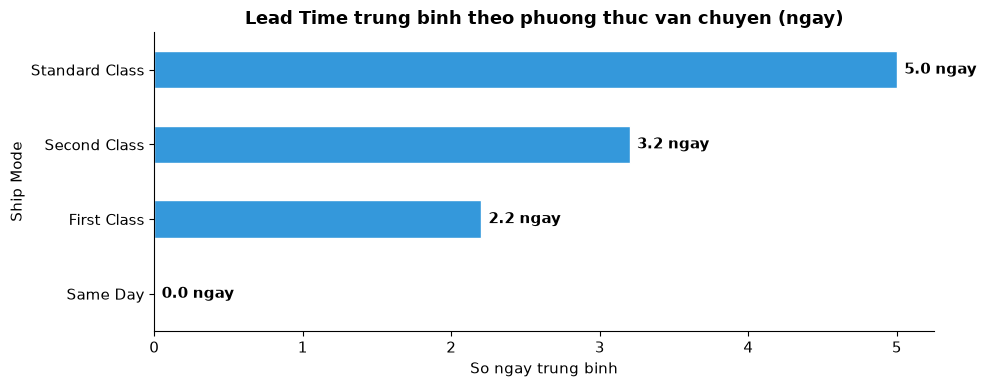


→ Kết quả hợp lý: Same Day nhanh nhất, Standard Class chậm nhất


In [25]:
# Lead Time theo Ship Mode — chỉ tính được sau khi có datetime
print('KIỂM CHỨNG LEAD TIME THEO PHƯƠNG THỨC VẬN CHUYỂN:')
print('(Dữ liệu này chỉ có được sau khi chuyển Date sang datetime)')
print()

lt_mode = df_clean.groupby('Ship Mode')['Ship Lead Time (Days)'].agg(['mean','min','max']).round(1)
lt_mode.columns = ['Trung bình (ngày)', 'Min (ngày)', 'Max (ngày)']
lt_mode = lt_mode.sort_values('Trung bình (ngày)')
print(lt_mode.to_string())

# Biểu đồ
fig, ax = plt.subplots(figsize=(10, 4))
lt_mode['Trung bình (ngày)'].plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Lead Time trung binh theo phuong thuc van chuyen (ngay)', fontweight='bold')
ax.set_xlabel('So ngay trung binh')
for i, v in enumerate(lt_mode['Trung bình (ngày)']):
    ax.text(v + 0.05, i, f'{v:.1f} ngay', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('→ Kết quả hợp lý: Same Day nhanh nhất, Standard Class chậm nhất')

In [26]:
# ============================================================
# FINAL VALIDATION CHECKLIST
# ============================================================
print('=' * 60)
print('FINAL VALIDATION CHECKLIST')
print('=' * 60)

kiem_tra = [
    ('Không có NULL trong toàn bộ dataset',      df_clean.isnull().sum().sum() == 0),
    ('Order Date là kiểu datetime64',            'datetime64' in str(df_clean['Order Date'].dtype)),
    ('Ship Date là kiểu datetime64',             'datetime64' in str(df_clean['Ship Date'].dtype)),
    ('Postal Code là kiểu string (object)',      df_clean['Postal Code'].dtype == 'object'),
    ('Tất cả ZIP code có đúng 5 chữ số',         (df_clean['Postal Code'].str.len() == 5).all()),
    ('Ship Date >= Order Date (logic đúng)',     (df_clean['Ship Date'] >= df_clean['Order Date']).all()),
    ('Lead Time >= 0 ngày',                      (df_clean['Ship Lead Time (Days)'] >= 0).all()),
    ('Sales >= 0 (doanh thu không âm)',          (df_clean['Sales'] >= 0).all()),
    ('Quantity >= 1 (số lượng hợp lệ)',          (df_clean['Quantity'] >= 1).all()),
    ('Discount trong phạm vi [0, 1]',            ((df_clean['Discount'] >= 0) & (df_clean['Discount'] <= 1)).all()),
    ('Profit Status có giá trị hợp lệ',         df_clean['Profit Status'].isin(['Profit','Loss','Break Even']).all()),
    ('Số dòng giữ nguyên (không mất dữ liệu)',  len(df_clean) == len(df_raw)),
    ('Có cột Year, Month, Quarter',              all(c in df_clean.columns for c in ['Year','Month','Quarter'])),
    ('Có cột Ship Lead Time (Days)',             'Ship Lead Time (Days)' in df_clean.columns),
]

tat_ca_dat = True
for ten, ket_qua in kiem_tra:
    icon = '✅ PASS' if ket_qua else '❌ FAIL'
    print(f'  {icon}  {ten}')
    if not ket_qua:
        tat_ca_dat = False

print()
tong = len(kiem_tra)
dat  = sum(1 for _, r in kiem_tra if r)
print(f'  Tổng kết: {dat}/{tong} kiểm tra đạt')
print()
if tat_ca_dat:
    print('  🎉 TẤT CẢ KIỂM TRA ĐẠT! Dữ liệu đã sẵn sàng cho phân tích EDA!')
else:
    print('  ⚠️  CÓ KIỂM TRA THẤT BẠI! Cần xem xét lại!')

FINAL VALIDATION CHECKLIST
  ✅ PASS  Không có NULL trong toàn bộ dataset
  ✅ PASS  Order Date là kiểu datetime64
  ✅ PASS  Ship Date là kiểu datetime64
  ❌ FAIL  Postal Code là kiểu string (object)
  ✅ PASS  Tất cả ZIP code có đúng 5 chữ số
  ✅ PASS  Ship Date >= Order Date (logic đúng)
  ✅ PASS  Lead Time >= 0 ngày
  ✅ PASS  Sales >= 0 (doanh thu không âm)
  ✅ PASS  Quantity >= 1 (số lượng hợp lệ)
  ✅ PASS  Discount trong phạm vi [0, 1]
  ✅ PASS  Profit Status có giá trị hợp lệ
  ✅ PASS  Số dòng giữ nguyên (không mất dữ liệu)
  ✅ PASS  Có cột Year, Month, Quarter
  ✅ PASS  Có cột Ship Lead Time (Days)

  Tổng kết: 13/14 kiểm tra đạt

  ⚠️  CÓ KIỂM TRA THẤT BẠI! Cần xem xét lại!


In [27]:
# Xem 5 dòng dữ liệu sau khi làm sạch
print('Dữ liệu sau khi làm sạch (5 dòng đầu):')
df_clean.head()

Dữ liệu sau khi làm sạch (5 dòng đầu):


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Ship Lead Time (Days),Profit Status,Year,Month,Quarter
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,Profit,2013,11,4
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,Profit,2013,11,4
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,Profit,2013,6,2
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,Loss,2012,10,4
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,Profit,2012,10,4


In [28]:
# Thống kê cuối cùng
print('THỐNG KÊ CUỐI CÙNG:')
print(df_clean.describe(include='all').T[['count','unique','top','freq','mean','std','min','max']].to_string())

THỐNG KÊ CUỐI CÙNG:


                        count unique              top  freq                        mean          std                  min                  max
Row ID                 9994.0    NaN              NaN   NaN                      4997.5  2885.163629                  1.0               9994.0
Order ID                 9994   5009   CA-2014-100111    14                         NaN          NaN                  NaN                  NaN
Order Date               9994    NaN              NaN   NaN  2013-04-30 19:20:02.401440          NaN  2011-01-04 00:00:00  2014-12-31 00:00:00
Ship Date                9994    NaN              NaN   NaN  2013-05-04 18:20:49.229537          NaN  2011-01-08 00:00:00  2015-01-06 00:00:00
Ship Mode                9994      4   Standard Class  5968                         NaN          NaN                  NaN                  NaN
Customer ID              9994    793         WB-21850    37                         NaN          NaN                  NaN                  NaN

In [29]:
# Lưu file đã làm sạch
df_clean.to_csv('../data/Superstore_clean.csv', index=False, encoding='utf-8-sig')

print('💾 Đã lưu: ../data/Superstore_clean.csv')
print(f'   {df_clean.shape[0]:,} dòng × {df_clean.shape[1]} cột')
print()
print('Dữ liệu đã sẵn sàng cho bước tiếp theo: EDA (Exploratory Data Analysis)!')

💾 Đã lưu: ../data/Superstore_clean.csv
   9,994 dòng × 26 cột

Dữ liệu đã sẵn sàng cho bước tiếp theo: EDA (Exploratory Data Analysis)!
